# PR20 · Extract region signals with coverage and confounds visible

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP02](../../curriculum/papers/processing.md#pp02), [PP06](../../curriculum/papers/processing.md#pp06).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** What evidence distinguishes a functional edge, a tractography edge, and a direct biological connection?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Distinguish atlas labels, template space and participant anatomy.
- Audit regional averaging and retained voxel coverage.
- Demonstrate a dependence introduced by global-signal removal.

## Understand the operation

A parcellation groups samples into named or numbered regions according to anatomical, functional or other criteria. Its boundaries define the measurement scale. A template image is a spatial reference; a label map is an assignment of regions; neither is interchangeable with an individual’s anatomy. Record the atlas version, space, resolution, label table and registration path before extracting a feature table.

A regional mean reduces many voxel time courses to one. It may reduce noise under suitable assumptions, but it also discards within-region heterogeneity and can cancel opposing responses. Missing coverage matters: a mean over a small surviving part of a region may describe a different measurement than a mean over the full parcel. Label masks must be resampled with an appropriate categorical method, and partial-volume contamination or smoothing across borders can mix signals.

Correlation summarizes linear co-fluctuation; it does not establish a direct tract, causal influence or the direction of communication. Confound handling changes this representation. In a system with only two regional signals, their average is the global signal. Regressing that global signal from both leaves residuals whose sum is zero, producing perfect anticorrelation when residual variance remains. This is a deliberately constrained mathematical example, not a claim that every negative correlation in real brain data is an artifact. It shows why nuisance choices and correlation interpretation must be reported together.

The lab compares original and globally residualized region correlations and quantifies how much signal an incorrect region assignment can mix. It prepares inputs for later modeling, where population-learned parcellations or transforms must be fit inside the training design.

## Transformation contract

**Input:** time-by-voxel values, categorical region IDs, coverage and confounds. **Output:** regional time courses and association matrix. **Preserved:** chosen averages, then linear association. **Lost:** voxel detail, amplitudes/offsets in correlation, and any component removed by regression.


## Read the actual course material

- [DartBrains: Parcellations](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Parcellations.py). CC BY-SA 4.0; linked pinned chapter.
- [DartBrains: Separating Signal from Noise with ICA](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/ICA.py). CC BY-SA 4.0; linked pinned chapter.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Extract regional means using explicit labels and report coverage counts. Derive why two-region global regression forces opposite residuals. Keep this demonstration distinct from a universal recommendation to include or exclude global signal. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
n=240; t=np.arange(n)
a=np.sin(2*np.pi*3*t/n); b=np.cos(2*np.pi*5*t/n)
voxels=np.column_stack([a,a,a,b,b,b])
labels=np.array([1,1,1,2,2,2])
regions=np.column_stack([voxels[:,labels==k].mean(1) for k in [1,2]])
C=np.corrcoef(regions,rowvar=False)
global_signal=regions.mean(1)
X=np.column_stack([np.ones(n),global_signal])
residual=regions-X@np.linalg.lstsq(X,regions,rcond=None)[0]
C_after=np.corrcoef(residual,rowvar=False)
print('before/after global regression:',C[0,1],C_after[0,1])
assert abs(C[0,1])<1e-12 and np.isclose(C_after[0,1],-1)
assert np.allclose(residual.sum(1),0,atol=1e-12)


before/after global regression: 5.181040781584064e-17 -1.0


covered/expected voxel counts: {1: 2, 2: 1} expected3 each


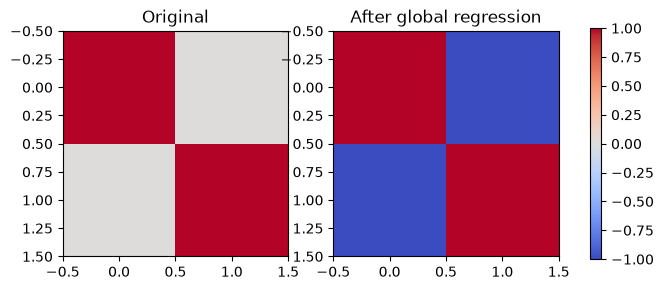

In [2]:
wrong_labels=np.array([1,1,2,1,2,2])
wrong_regions=np.column_stack([voxels[:,wrong_labels==k].mean(1) for k in [1,2]])
coverage=np.array([True,True,False,True,False,False])
counts={k:int(np.count_nonzero(coverage & (labels==k))) for k in [1,2]}
print('covered/expected voxel counts:',counts,'expected3 each')
assert counts=={1:2,2:1} and not np.allclose(wrong_regions,regions)
fig,axes=plt.subplots(1,2,figsize=(8,3))
for ax,matrix,title in zip(axes,[C,C_after],['Original','After global regression']):
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap='coolwarm'); ax.set_title(title)
fig.colorbar(im,ax=axes); plt.show()


## Check and explain

The original signals have correlation0 to numerical precision; residual correlation is−1 after this constructed global regression. Coverage is2/3 voxels for region1 and1/3 for region2. Incorrect label assignments change the measured time courses despite identical output shape.

## Deliberately wrong method

Using a matching-sized atlas without checking its world space can mix unrelated anatomy. Reporting only the final correlation matrix hides low coverage and the effect of nuisance choices. Do not call the imposed anticorrelation evidence of inhibitory neural influence.

## Transfer to an actual dataset or tool — guided assignment

Read DartBrains Parcellations, select one documented atlas appropriate to a teaching question, and overlay it on an independently QC-approved derivative in the same space. Report expected/retained voxel counts per parcel and show at least one boundary. Extract signals using a documented confound strategy, record label order, and compare one sensitivity variant chosen before outcome testing. Any atlas downloads and real signals are separate from this offline lab.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Is a regional mean lossless? **Answer:** no; many different voxel patterns produce the same mean.
2. Why can preprocessing change correlations? **Answer:** removing shared components and mixing spatial samples changes the covariance structure on which correlations depend.


### Return to the research question

Reopen [PP02](../../curriculum/papers/processing.md#pp02), [PP06](../../curriculum/papers/processing.md#pp06) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
